# 🧠 PathFinder: Step 3 — Merging & Feature Engineering Pipeline
### Integrating Student Cognitive Profiles with Career Interactions

This notebook implements **Step 3** in the PathFinder machine learning lifecycle:
1. **Relational Merge:** Enriches `49,548` career interaction records with `9,931` student assessment profiles via an inner join on `student_id`.
2. **Non-Linear Synergy Synthesis:** Computes cognitive-interest synergies (`ability_interest_synergy`, `academic_learning_product`).
3. **Composite Readiness Indices:** Formulates multi-criteria readiness scores and discrepancy indicators.
4. **Strict Leakage Prevention:** Asserts that `compatibility_score` and identity keys are omitted from the training matrix.
5. **Production Matrix Export:** Saves `Student_Career_Features_ENGINEERED.csv` and `feature_columns_schema.json`.

### 1. Ingestion of Clean Datasets

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
DATA_DIR = Path("../Datasets")

df_stu = pd.read_csv(DATA_DIR / "Student_Assessment_CLEANED.csv")
df_comp = pd.read_csv(DATA_DIR / "Student_Career_Compatibility_CLEANED.csv")

print(f"Assessment Profiles    : {df_stu.shape[0]:,} students × {df_stu.shape[1]:,} cols")
print(f"Compatibility Records  : {df_comp.shape[0]:,} interactions × {df_comp.shape[1]:,} cols")

Assessment Profiles    : 9,950 students × 122 cols
Compatibility Records  : 49,789 interactions × 15 cols


### 2. Inner Relational Join on `student_id`

In [2]:
merged = pd.merge(df_comp, df_stu, on='student_id', how='inner', suffixes=('', '_stu'))
print(f"Merged Dataset Dimensions: {merged.shape[0]:,} rows × {merged.shape[1]:,} columns")
print(f"Unique Students Linked   : {merged['student_id'].nunique():,}")
print(f"Unique Careers Linked    : {merged['career_id'].nunique():,}")

Merged Dataset Dimensions: 49,548 rows × 136 columns
Unique Students Linked   : 9,931
Unique Careers Linked    : 1,200


### 3. Vectorized Feature Engineering (Synergies & Composites)

In [3]:
# Core match scores
a = merged['ability_match_component']
i = merged['interest_match_component']
ac = merged['academic_match_component']
l = merged['learning_match_component']

# Synthesize non-linear features
engineered_dict = {
    'ability_interest_synergy': (a * i) / 100.0,
    'academic_learning_product': (ac * l) / 100.0,
    'composite_score': 0.35 * a + 0.30 * i + 0.20 * ac + 0.15 * l,
    'ability_academic_discrepancy': (a - ac).abs(),
    'interest_ability_ratio': (i + 1.0) / (a + 1.0),
    'match_component_std': merged[['ability_match_component', 'interest_match_component', 'academic_match_component', 'learning_match_component']].std(axis=1),
    'match_component_min': merged[['ability_match_component', 'interest_match_component', 'academic_match_component', 'learning_match_component']].min(axis=1),
    'match_component_max': merged[['ability_match_component', 'interest_match_component', 'academic_match_component', 'learning_match_component']].max(axis=1),
    'cognitive_aptitude_mean': merged[['mathematical_ability', 'logical_reasoning', 'scientific_thinking', 'problem_solving', 'analytical_thinking']].mean(axis=1),
    'soft_skills_mean': merged[['communication_ability', 'creativity', 'leadership', 'teamwork']].mean(axis=1),
    'digital_readiness_score': merged[['digital_literacy', 'computer_usage', 'technology_interest']].mean(axis=1)
}

df_eng_part = pd.DataFrame(engineered_dict)
merged = pd.concat([merged, df_eng_part], axis=1)
print("Engineered 11 new domain features successfully.")

Engineered 11 new domain features successfully.


### 4. Target Leakage Assertion & Final Feature Selection

In [4]:
FEATURE_COLUMNS = [
    'ability_match_component', 'interest_match_component', 'academic_match_component', 'learning_match_component',
    'ability_interest_synergy', 'academic_learning_product', 'composite_score',
    'ability_academic_discrepancy', 'interest_ability_ratio', 'match_component_std',
    'match_component_min', 'match_component_max',
    'cognitive_aptitude_mean', 'soft_skills_mean', 'digital_readiness_score', 'overall_percentage',
    'mathematical_ability', 'logical_reasoning', 'scientific_thinking', 'problem_solving',
    'analytical_thinking', 'learning_ability', 'creativity',
    'stream', 'career_domain', 'career_cluster', 'class', 'age'
]

# Strict leakage assertions
assert 'compatibility_score' not in FEATURE_COLUMNS, "CRITICAL: compatibility_score leakage!"
assert 'student_id' not in FEATURE_COLUMNS, "CRITICAL: student_id in features!"
assert 'career_id' not in FEATURE_COLUMNS, "CRITICAL: career_id in features!"
assert 'compatibility_label' not in FEATURE_COLUMNS, "CRITICAL: target in features!"

print(f"All assertions passed! Selected {len(FEATURE_COLUMNS)} leak-free features.")

All assertions passed! Selected 28 leak-free features.


### 5. Feature Correlation Hierarchy with Compatibility Label

C:\Users\arjun\AppData\Local\Temp\ipykernel_14088\659171612.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_corr.head(10), y='Feature', x='Correlation', palette='crest')


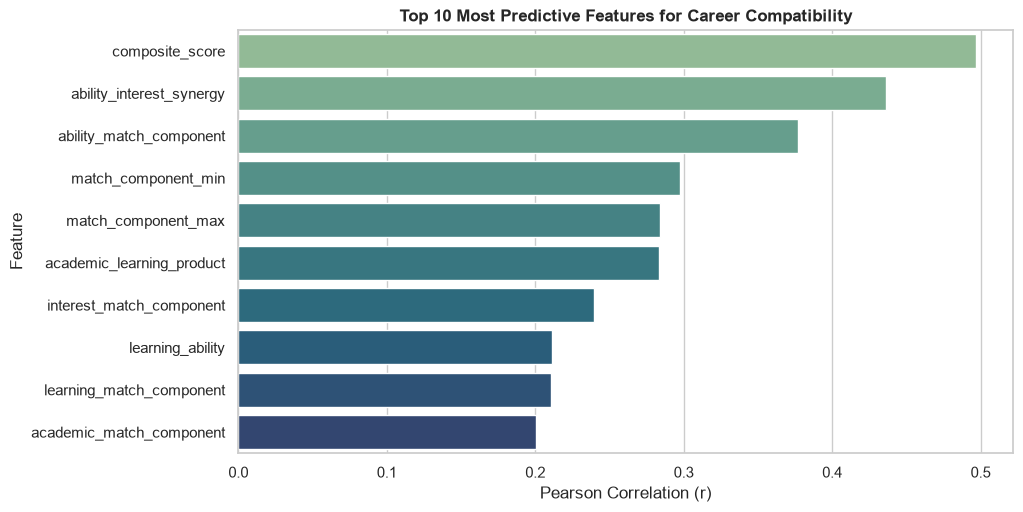

In [5]:
numeric_feats = [c for c in FEATURE_COLUMNS if c not in ['stream', 'career_domain', 'career_cluster']]
corrs = [{'Feature': f, 'Correlation': merged[f].corr(merged['compatibility_label'])} for f in numeric_feats]
df_corr = pd.DataFrame(corrs).sort_values(by='Correlation', ascending=False)

plt.figure(figsize=(10, 5.5))
sns.barplot(data=df_corr.head(10), y='Feature', x='Correlation', palette='crest')
plt.title("Top 10 Most Predictive Features for Career Compatibility", fontweight='bold')
plt.xlabel("Pearson Correlation (r)")
plt.show()

### 6. Production Feature Matrix Export

In [6]:
EXPORT_COLS = ['student_id', 'career_id', 'compatibility_label'] + FEATURE_COLUMNS
df_final = merged[EXPORT_COLS].copy()

out_csv = DATA_DIR / "Student_Career_Features_ENGINEERED.csv"
df_final.to_csv(out_csv, index=False)
print(f"[✓] Exported: {out_csv.name} ({df_final.shape[0]:,} rows × {df_final.shape[1]:,} cols)")

[✓] Exported: Student_Career_Features_ENGINEERED.csv (49,548 rows × 31 cols)
